# Technical Indicators Analysis

Calculate and visualize technical indicators.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.append('..')

from src.utils.config import DEFAULT_TICKERS, RAW_DATA_DIR
from src.preprocessing.feature_engineering import add_technical_indicators, add_price_features

%matplotlib inline

In [7]:
%pip install pandas_ta --quiet

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Load data (try multiple possible locations)
from pathlib import Path
# Use project tickers (DEFAULT_TICKERS) instead of AAPL
ticker = DEFAULT_TICKERS[1]  # change index to pick another project ticker
candidates = [
    Path('../data/processed') / f'{ticker}_cleaned.csv',
    Path('../../../../data/processed') / f'{ticker}_cleaned.csv',
    Path('data/processed') / f'{ticker}_cleaned.csv',
    Path('../../data/processed') / f'{ticker}_cleaned.csv'
]
data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break
if data_path is None:
    raise FileNotFoundError(f'Could not find {ticker}_cleaned.csv in: {candidates}')
print('Loading cleaned CSV from:', data_path)
data = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Add indicators
data = add_technical_indicators(data)
data = add_price_features(data)

data.tail()

Loading cleaned CSV from: ..\data\processed\TCS.NS_cleaned.csv
2025-12-17 17:38:24 - src.preprocessing.feature_engineering - INFO - Added technical indicators → 23 columns
2025-12-17 17:38:24 - src.preprocessing.feature_engineering - INFO - Added price-derived features


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI,...,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,returns,log_returns,range,range_pct,gap,gap_pct,volatility_20
Price,,,,,,,,,,,,,,,,,,,,,
2024-11-21,3935.940918,3954.881921,3888.732920,3908.930271,2384347,3941.516663,4004.688027,3954.937248,3959.620131,47.519860,...,40.715427,49.606386,-8.890959,0.008244,0.008210,66.149001,0.016806,5.170261,0.001324,0.014907
2024-11-22,4101.917480,4111.919659,3917.724422,3934.152966,3096553,3950.134412,4006.527710,3977.549591,3970.160675,61.025068,...,62.007590,50.340967,11.666623,0.042169,0.041305,194.195236,0.047343,-1.787952,-0.000454,0.017395
2024-11-28,4102.207031,4194.062196,4090.707146,4173.816244,2558544,3959.653296,4008.195239,3996.727659,3979.941887,61.043902,...,74.802462,59.175160,15.627302,0.000071,0.000071,103.355050,0.025195,71.898764,0.017528,0.017331
2024-11-29,4127.285156,4154.199071,4054.612821,4078.144388,2017425,3969.959802,4008.077993,4016.813428,3990.856203,62.724032,...,85.790192,74.200082,11.590111,0.006113,0.006095,99.586250,0.024129,-24.062643,-0.005866,0.017349
2024-12-02,4132.889648,4144.051677,4087.856020,4126.463284,1670944,3978.937512,4008.155757,4034.671308,4001.377199,63.106979,...,81.014250,80.535635,0.478615,0.001358,0.001357,56.195656,0.013597,-0.821873,-0.000199,0.017302


## Moving Averages

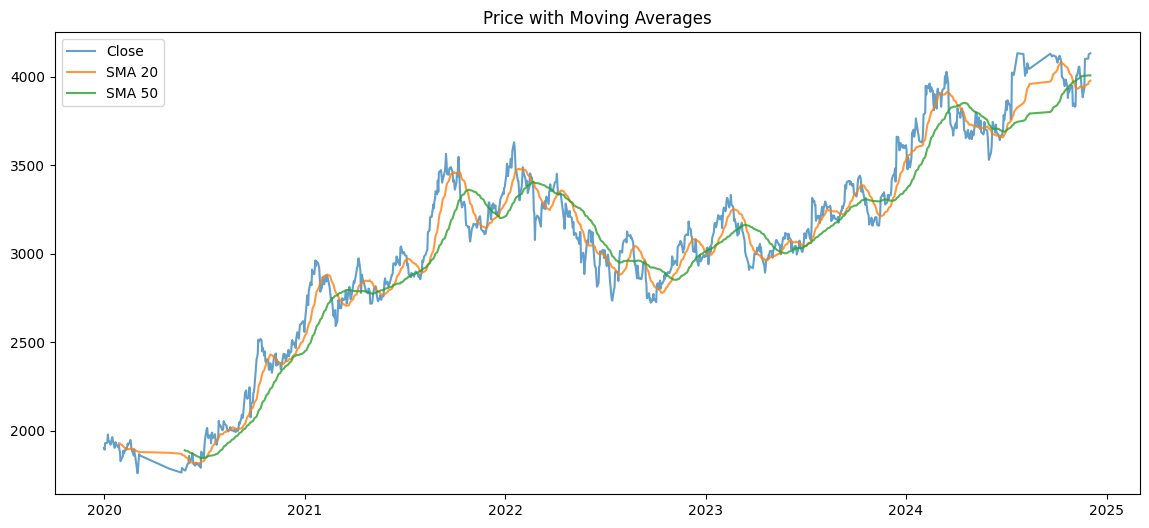

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], label='Close', alpha=0.7)
plt.plot(data.index, data['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(data.index, data['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('Price with Moving Averages')
plt.legend()
plt.show()

## RSI

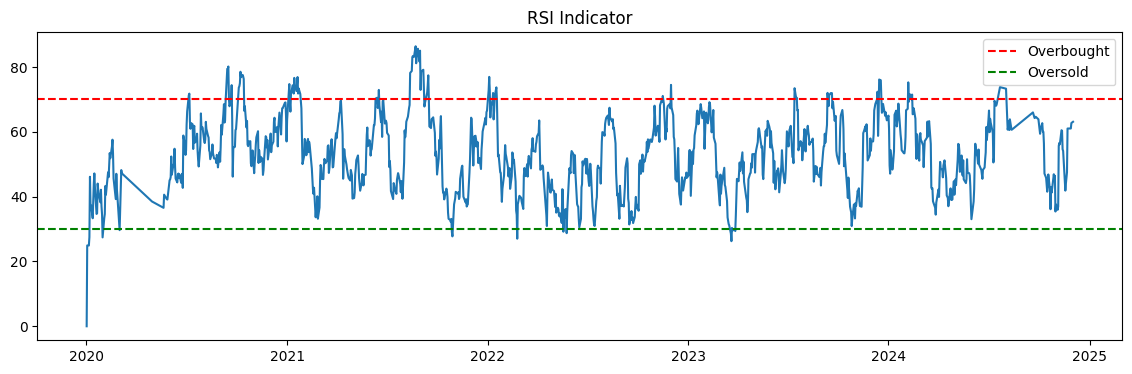

In [12]:
plt.figure(figsize=(14, 4))
plt.plot(data.index, data['RSI'])
plt.axhline(y=70, color='r', linestyle='--', label='Overbought')
plt.axhline(y=30, color='g', linestyle='--', label='Oversold')
plt.title('RSI Indicator')
plt.legend()
plt.show()